In [1]:
import os
from pandas import read_csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
sns.set(font_scale=1.2)  # larger font

In [2]:
input_dir = '/Users/cpoliziani/Documents/repo/SynthFirm/RawData/SUSB'
msa_file = 'msa_3digitnaics_2016.csv'

susb_msa_3naics = read_csv(os.path.join(input_dir, msa_file))
print(len(susb_msa_3naics))
susb_msa_3naics.head(10)






588675


,MSA,NAICS,ENTRSIZE,FIRM,ESTB,EMPL,EMPLFL_R,EMPLFL_N,PAYR,PAYRFL_N,MSADSCR,NAICSDSCR,ENTRSIZEDSCR
0,10100,--,1,1342,1418,19533,NaN,G,746190,H,"Aberdeen, SD Micro Area",Total,01: Total
1,10100,--,2,663,663,1076,NaN,H,41114,G,"Aberdeen, SD Micro Area",Total,02: 0-4
2,10100,--,3,216,216,1442,NaN,G,45082,G,"Aberdeen, SD Micro Area",Total,03: 5-9
3,10100,--,4,139,143,1759,NaN,G,58959,G,"Aberdeen, SD Micro Area",Total,04: 10-19
4,10100,--,5,1018,1022,4277,NaN,G,145155,G,"Aberdeen, SD Micro Area",Total,05: <20
5,10100,--,6,132,149,3694,NaN,G,125447,G,"Aberdeen, SD Micro Area",Total,06: 20-99
6,10100,--,7,62,78,3731,NaN,H,121504,H,"Aberdeen, SD Micro Area",Total,07: 100-499
7,10100,--,8,1212,1249,11702,NaN,G,392106,G,"Aberdeen, SD Micro Area",Total,08: <500
8,10100,--,9,130,169,7831,NaN,H,354084,H,"Aberdeen, SD Micro Area",Total,09: 500+
9,10100,11,1,8,8,20,NaN,G,1161,H,"Aberdeen, SD Micro Area","Agriculture, Forestry, Fishing and Hunting",01: Total


In [3]:
# Data are aggregated in different ways - split the data to double check wether the totals match

# ENTRSIZE
# 1 = total
# 2, 3, 4, 6, 7, 9 = total
# 2, 3, 4 = 5
# 6, 7 = 8
# NAICS
# -- - Total
# 3 Digit and 2 Digits

susb_msa_3naics.loc[:, 'digit_count'] = \
    susb_msa_3naics['NAICS'].str.len()

susb_msa_2naics = susb_msa_3naics[(susb_msa_3naics['digit_count']==2) | (susb_msa_3naics['digit_count']==5)]
susb_msa_2naics = susb_msa_2naics[susb_msa_2naics['NAICS']!='--']
susb_msa_3naics = susb_msa_3naics[susb_msa_3naics['digit_count']==3]

susb_msa_2naics_DetailedEntrSize = susb_msa_2naics[susb_msa_2naics['ENTRSIZE'].isin([2,3,4,6,7,9])]
susb_msa_2naics_TotalEntrSize = susb_msa_2naics[susb_msa_2naics['ENTRSIZE'] == 1]
susb_msa_3naics_DetailedEntrSize = susb_msa_3naics[susb_msa_3naics['ENTRSIZE'].isin([2,3,4,6,7,9])]
susb_msa_3naics_TotalEntrSize = susb_msa_3naics[susb_msa_3naics['ENTRSIZE'] == 1]

print('--FIRM--')
print(susb_msa_2naics_DetailedEntrSize.FIRM.sum())
print(susb_msa_2naics_TotalEntrSize.FIRM.sum())
print(susb_msa_3naics_DetailedEntrSize.FIRM.sum())
print(susb_msa_3naics_TotalEntrSize.FIRM.sum())
print('--ESTB--')
print(susb_msa_2naics_DetailedEntrSize.ESTB.sum())
print(susb_msa_2naics_TotalEntrSize.ESTB.sum())
print(susb_msa_3naics_DetailedEntrSize.ESTB.sum())
print(susb_msa_3naics_TotalEntrSize.ESTB.sum())
print('--EMPL--')
print(susb_msa_2naics_DetailedEntrSize.EMPL.sum())
print(susb_msa_2naics_TotalEntrSize.EMPL.sum())
print(susb_msa_3naics_DetailedEntrSize.EMPL.sum())
print(susb_msa_3naics_TotalEntrSize.EMPL.sum())


--FIRM--
6181879
6181879
6189864
6189864
--ESTB--
7311519
7311519
7295131
7295131
--EMPL--
115316969
116716637
109355865
114535582


65566
Avg and Max establishments per firm (average per MSA and NAICS, not for single establishments)
1.1572429207678248
12.666666666666666


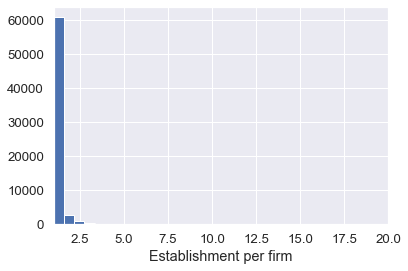

In [4]:
SUSB = susb_msa_3naics_TotalEntrSize[['MSA','NAICS','FIRM', 'ESTB', 'EMPL', 'MSADSCR', 'ENTRSIZE', 'ENTRSIZEDSCR']].copy()

# establishment per firm distribution
print(len(SUSB))
SUSB.loc[:, 'est_per_firm'] = \
    SUSB.loc[:, 'ESTB'] / \
    SUSB.loc[:, 'FIRM']
SUSB.loc[:, 'est_per_firm'].hist(bins = 20, density = False)
print('Avg and Max establishments per firm (average per MSA and NAICS, not for single establishments)')
print(SUSB.loc[:, 'est_per_firm'].mean())
print(SUSB.loc[:, 'est_per_firm'].max())
plt.xlim([1, 20])
plt.xlabel('Establishment per firm')
SUSB.to_csv(os.path.join('/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/SynthFirm_parameters', 
                                          'SUSB_msa_3digitnaics_2016.csv'))

In [5]:
SUSB

,MSA,NAICS,FIRM,ESTB,EMPL,MSADSCR,ENTRSIZE,ENTRSIZEDSCR,est_per_firm
14,10100,115,8,8,20,"Aberdeen, SD Micro Area",1,01: Total,1.000000
24,10100,212,3,3,24,"Aberdeen, SD Micro Area",1,01: Total,1.000000
36,10100,221,7,9,134,"Aberdeen, SD Micro Area",1,01: Total,1.285714
52,10100,236,64,64,272,"Aberdeen, SD Micro Area",1,01: Total,1.000000
60,10100,237,9,9,53,"Aberdeen, SD Micro Area",1,01: Total,1.000000
...,...,...,...,...,...,...,...,...,...
588644,49820,721,4,4,21,"Zapata, TX Micro Area",1,01: Total,1.000000
588650,49820,722,15,15,144,"Zapata, TX Micro Area",1,01: Total,1.000000
588663,49820,811,1,1,0,"Zapata, TX Micro Area",1,01: Total,1.000000
588667,49820,812,1,1,0,"Zapata, TX Micro Area",1,01: Total,1.000000


In [17]:
SUSB.est_per_firm.describe()

count    65566.000000
mean         1.157243
std          0.442607
min          1.000000
25%          1.000000
50%          1.000000
75%          1.120245
max         12.666667
Name: est_per_firm, dtype: float64

In [58]:
# adding costar data
costar_file = 'Costar_Firm_and_estb_dist_GT5estb.csv'
costar_data = read_csv(os.path.join(input_dir, costar_file))
print(costar_data)

        firm_id  FAF_Zone   naics6d employees  N
0          9030       486       NaN        40  3
1          9030       129       NaN        40  1
2          9030        89       NaN        40  1
3          9030       484       NaN        40  1
4          9030       401       NaN        40  1
...         ...       ...       ...       ... ..
454371     6528       481  517919.0       500  4
454372    21304       341  561330.0       140  1
454373    21304       122  561330.0       140  1
454374    21304       363  561330.0       140  2
454375    21304        92  561330.0       140  1

[454376 rows x 5 columns]


In [59]:
n0 = len(costar_data)
# add NAICS3 (keep NAICS6)
costar_data["naics3"] = costar_data["naics6d"].apply(
    lambda x: f"{int(x):06d}"[:3] if pd.notna(x) else np.nan
)
# report + drop NAICS-missing
n_na = costar_data["naics6d"].isna().sum()
print(f"naics6d NaN rows: {n_na}/{n0} ({n_na/n0:.2%})")
costar_data = costar_data.dropna(subset=["naics6d"]).copy()

costar_data = costar_data.rename(columns={"employees": "employees_total"})

# total establishments per firm (sum of N within firm_id)
costar_data["N_total"] = costar_data.groupby(["firm_id","employees_total"])["N"].transform("sum")

costar_data["employees_total"] = pd.to_numeric(
    costar_data["employees_total"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

n0 = len(costar_data)
costar_data = costar_data.dropna(subset=["employees_total", "N_total"]).copy()
print(f"dropped: {n0-len(costar_data)}/{n0} ({(n0-len(costar_data))/n0:.2%})")

costar_data = costar_data[costar_data["N_total"] > 0].copy()

costar_data["employees"] = costar_data["employees_total"].astype(int) / costar_data["N_total"].astype(int) * costar_data["N"].astype(int)
costar_data["employees_per_estb"] = costar_data["employees_total"].astype(int) / costar_data["N_total"].astype(int)



naics6d NaN rows: 6283/454376 (1.38%)
dropped: 1636/448093 (0.37%)


In [60]:
costar_data.employees.sum()

206129846.00000006

In [44]:
costar_data[costar_data.employees_total == 1290000.0]


,firm_id,FAF_Zone,naics6d,employees_total,N,naics3,N_total,employees,employees_per_estb
77911,21079,399,334419.0,1290000.0,1,334,23,56086.956522,56086.956522
77912,21079,551,334419.0,1290000.0,5,334,23,280434.782609,56086.956522
77913,21079,511,334419.0,1290000.0,1,334,23,56086.956522,56086.956522
77914,21079,182,334419.0,1290000.0,1,334,23,56086.956522,56086.956522
77915,21079,486,334419.0,1290000.0,4,334,23,224347.826087,56086.956522
77916,21079,485,334419.0,1290000.0,1,334,23,56086.956522,56086.956522
77917,21079,64,334419.0,1290000.0,4,334,23,224347.826087,56086.956522
77918,21079,481,334419.0,1290000.0,1,334,23,56086.956522,56086.956522
77919,21079,531,334419.0,1290000.0,1,334,23,56086.956522,56086.956522
77920,21079,63,334419.0,1290000.0,1,334,23,56086.956522,56086.956522


In [43]:
out = (costar_data.groupby("firm_id", as_index=False)["employees_total"]
       .first()
       .sort_values("employees_total", ascending=False))

out[:40]

,firm_id,employees_total
9,10,2870000.0
89,90,2300000.0
88,89,1541000.0
48,49,1500000.0
19518,20250,1327892.0
20307,21079,1290000.0
30362,31431,1290000.0
25893,26871,935000.0
144,145,800000.0
6699,6899,800000.0


In [22]:
costar_firms = (costar_data
    .groupby(["firm_id"], as_index=False)
    .agg(
        employees_total=("employees_total", "first"),   # firm total (avoid double count)
        N_total=("N_total", "first"),                   # firm total (avoid double count)
        N=("N", lambda s: set(s.astype(int))),
        naics6_list=("naics6d", lambda s: set(s.astype(int))),
        naics3_list=("naics3",  lambda s: set(s.astype(str))),
        faf_list=("FAF_Zone",   lambda s: set(s.astype(int)))
    )
)
# list lengths (if not already present)
costar_firms["n_naics6"] = costar_firms["naics6_list"].apply(len)
costar_firms["n_naics3"] = costar_firms["naics3_list"].apply(len)
costar_firms["n_faf"] = costar_firms["faf_list"].apply(len)

costar_firms["employees_per_estb"] = costar_firms["employees_total"] / costar_firms["N_total"]
print(len(costar_firms), "unique firms")
costar_firms.head()

31745 unique firms


,firm_id,employees_total,N_total,N,naics6_list,naics3_list,faf_list,n_naics6,n_naics3,n_faf,employees_per_estb
0,1,122000.0,7624,"{384, 1, 2, 3, 4, 5, 6, 7, 8, 137, 10, 11, 140...","{445120, 457120, 447110, 445131, 424720, 45711...","{213, 447, 457, 424, 811, 445}","{512, 513, 519, 11, 12, 19, 20, 531, 539, 540,...",8,6,125,16.002099
1,2,127468.0,1853,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{923130, 813211, 459110, 813319}","{459, 813, 923}","{512, 513, 519, 11, 12, 531, 532, 20, 19, 539,...",4,3,129,68.790070
2,3,63500.0,2209,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{541890, 458210, 337127, 448140, 713940, 44815...","{541, 713, 458, 337, 448}","{512, 513, 519, 11, 12, 531, 19, 532, 20, 539,...",8,5,130,28.746039
3,4,5000.0,2832,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{493110, 531130, 541614}","{493, 531, 541}","{512, 513, 519, 11, 12, 19, 531, 532, 539, 551...",3,3,113,1.765537
4,5,4150.0,2315,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{238210, 332812, 238220, 811412, 425110, 44419...","{444, 238, 236, 337, 531, 562, 523, 551, 339, ...","{512, 513, 519, 11, 12, 19, 20, 531, 532, 539,...",29,22,128,1.792657


In [23]:
costar_data

,firm_id,FAF_Zone,naics6d,employees_total,N,naics3,N_total,employees,employees_per_estb
15,17592,61,492110.0,1896.0,8,492,29,523.034483,65.37931
16,17592,531,492110.0,1896.0,2,492,29,130.758621,65.37931
17,17592,262,492110.0,1896.0,1,492,29,65.379310,65.37931
18,17592,321,492110.0,1896.0,2,492,29,130.758621,65.37931
19,17592,64,492110.0,1896.0,9,492,29,588.413793,65.37931
...,...,...,...,...,...,...,...,...,...
454371,6528,481,517919.0,500.0,4,517,5,400.000000,100.00000
454372,21304,341,561330.0,140.0,1,561,5,28.000000,28.00000
454373,21304,122,561330.0,140.0,1,561,5,28.000000,28.00000
454374,21304,363,561330.0,140.0,2,561,5,56.000000,28.00000


In [24]:
costar_firms

,firm_id,employees_total,N_total,N,naics6_list,naics3_list,faf_list,n_naics6,n_naics3,n_faf,employees_per_estb
0,1,122000.0,7624,"{384, 1, 2, 3, 4, 5, 6, 7, 8, 137, 10, 11, 140...","{445120, 457120, 447110, 445131, 424720, 45711...","{213, 447, 457, 424, 811, 445}","{512, 513, 519, 11, 12, 19, 20, 531, 539, 540,...",8,6,125,16.002099
1,2,127468.0,1853,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{923130, 813211, 459110, 813319}","{459, 813, 923}","{512, 513, 519, 11, 12, 531, 532, 20, 19, 539,...",4,3,129,68.790070
2,3,63500.0,2209,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{541890, 458210, 337127, 448140, 713940, 44815...","{541, 713, 458, 337, 448}","{512, 513, 519, 11, 12, 531, 19, 532, 20, 539,...",8,5,130,28.746039
3,4,5000.0,2832,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{493110, 531130, 541614}","{493, 531, 541}","{512, 513, 519, 11, 12, 19, 531, 532, 539, 551...",3,3,113,1.765537
4,5,4150.0,2315,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{238210, 332812, 238220, 811412, 425110, 44419...","{444, 238, 236, 337, 531, 562, 523, 551, 339, ...","{512, 513, 519, 11, 12, 19, 20, 531, 532, 539,...",29,22,128,1.792657
...,...,...,...,...,...,...,...,...,...,...,...
31740,32848,2560.0,7,"{1, 6}",{313110},{313},"{372, 61}",1,1,2,365.714286
31741,32849,104874.0,35,"{1, 2, 4}","{334419, 335220}","{334, 335}","{131, 391, 393, 139, 19, 532, 171, 181, 189, 6...",2,2,23,2996.400000
31742,32850,640.0,8,"{1, 2}","{488210, 813410}","{813, 488}","{512, 484, 171, 371, 531, 61}",2,2,6,80.000000
31743,32851,39000.0,55,"{8, 1, 2, 3}","{311811, 311423, 311999}",{311},"{131, 391, 519, 393, 269, 399, 271, 291, 292, ...",3,1,31,709.090909


In [11]:
# add list lengths
costar_firms["n_naics6"] = costar_firms["naics6_list"].apply(len)
costar_firms["n_naics3"] = costar_firms["naics3_list"].apply(len)
costar_firms["n_faf"]    = costar_firms["faf_list"].apply(len)

def line(label, s):
    print(f"{label}: mean={s.mean():,.2f} | min={s.min():,.2f} | max={s.max():,.2f}")

print(f"Total firms: {len(costar_firms):,}")
print(f"Total establishments: {costar_firms.N_total.sum():,}\n")

line("employees_total",      costar_firms["employees_total"])
line("N_total",              costar_firms["N_total"])
line("employees_per_estb",   costar_firms["employees_per_estb"])
line("len(naics6_list)",     costar_firms["n_naics6"])
line("len(naics3_list)",     costar_firms["n_naics3"])
line("len(faf_list)",        costar_firms["n_faf"])

Total firms: 31,745
Total establishments: 2,415,903

employees_total: mean=6,493.30 | min=1.00 | max=2,870,000.00
N_total: mean=76.10 | min=1.00 | max=30,297.00
employees_per_estb: mean=305.52 | min=0.01 | max=75,000.00
len(naics6_list): mean=1.42 | min=1.00 | max=88.00
len(naics3_list): mean=1.28 | min=1.00 | max=45.00
len(faf_list): mean=12.65 | min=1.00 | max=132.00


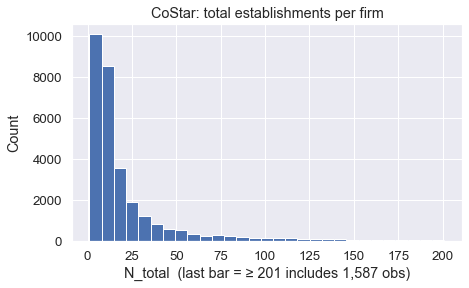

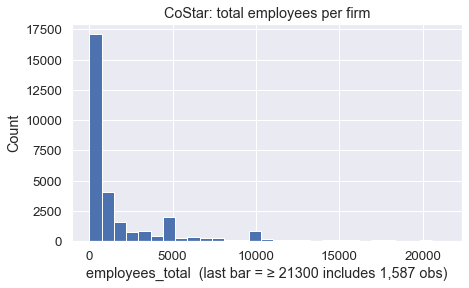

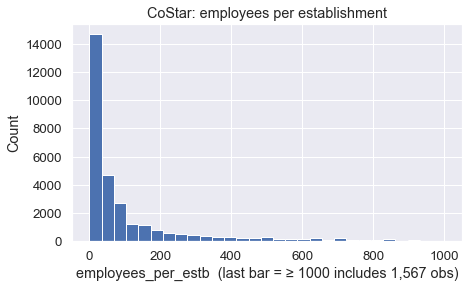

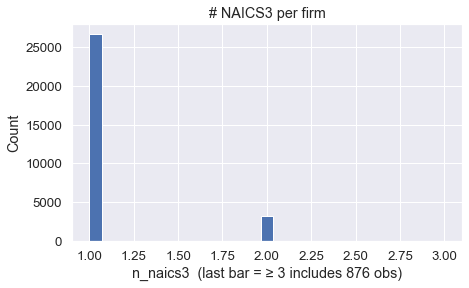

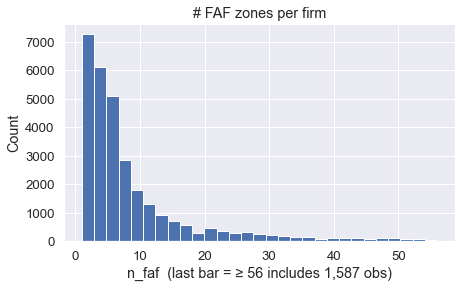

In [12]:
def hist_int(s, title, xlabel, q=0.95, bins=30):
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    cut = x.quantile(q)

    x_in  = x[x <= cut]
    x_out = x[x >  cut]
    n_out = len(x_out)

    # bins on the in-range data + one extra bin for the tail
    edges = np.linspace(x_in.min(), cut, bins)
    edges = np.r_[edges, np.inf]  # last bin = [cut, +inf)

    plt.figure(figsize=(7,4))
    plt.hist(x, bins=edges)
    plt.title(title)
    plt.xlabel(f"{xlabel}  (last bar = ≥ {cut:.0f} includes {n_out:,} obs)")
    plt.ylabel("Count")
    plt.show()

# 1) N_total
hist_int(costar_firms["N_total"], "CoStar: total establishments per firm", "N_total")

# 2) employees_total
hist_int(costar_firms["employees_total"], "CoStar: total employees per firm", "employees_total")

# 3) employees_per_estb
hist_int(costar_firms["employees_per_estb"], "CoStar: employees per establishment", "employees_per_estb")

# 4) how multi-activity / multi-geo are firms
hist_int(costar_firms["n_naics3"], "# NAICS3 per firm", "n_naics3")
hist_int(costar_firms["n_faf"],   "# FAF zones per firm", "n_faf")


In [13]:
costar_data.to_csv(os.path.join('/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/SynthFirm_parameters', 
                                          'Costar_Data_GT5estb.csv'))
costar_firms.to_csv(os.path.join('/Users/cpoliziani/Documents/repo/SynthFirm_input_parameter_111125/SynthFirm_parameters', 
                                          'Costar_Firm_GT5estb.csv'))

In [14]:
# Conclusions
# SUSB Copre tutto US ma aggrega dati per Metropolitan Area a NAICS
# Costar più dettagliato (Establishment level) but lower covergae
# Then..Use SUSB to match totals and Costar to distribute over NAICS and FAF (better County if available)